# Análisis de Ratios Financieros: Apalancamiento y Rentabilidad por Industria

**Autora:** Daniela Araya Cáceres — Ingeniera Comercial, Diplomado en Python y Data Science (PUC)

## Objetivo

Un gestor de hedge fund necesita comparar la salud financiera de un conjunto de empresas de tres
industrias (tecnología, bienes de consumo masivo e inmobiliario) a partir de sus balances y estados
de resultados. Este notebook calcula dos familias de ratios financieros —apalancamiento y
rentabilidad— y responde tres preguntas de negocio para orientar decisiones de inversión.

Este proyecto aplica directamente herramientas que uso en mi rol de Análisis de Datos en Punto Ticket
(conciliaciones, análisis financiero y automatización de reportes): pandas para manipulación de datos,
agregaciones por grupo y visualización con seaborn.

## Datos

- `data/Balance_Sheet.xlsx`: balance general por empresa y año (activos, pasivos, patrimonio).
- `data/Income_Statement.xlsx`: estado de resultados por empresa y año (ingresos, costos, utilidades).

Ambos comparten las columnas `company` (ticker), `comp_type` (`tech`, `fmcg`, `real_est`) y `Year`.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 1. Carga de datos

In [2]:
balance_sheet = pd.read_excel("data/Balance_Sheet.xlsx")
income_statement = pd.read_excel("data/Income_Statement.xlsx")

print(balance_sheet.shape, income_statement.shape)
balance_sheet.head()


(60, 13) (60, 8)


,Year,comp_type,company,Accounts Payable,Cash,Inventory,Property Plant Equipment,Short Term Investments,Total Assets,Total Current Assets,Total Current Liabilities,Total Liab,Total Stockholder Equity
0,2019,tech,AAPL,46236000000,48844000000,"4,106,000,000.000",37378000000,"51,713,000,000.000",338516000000,162819000000,105718000000,248028000000,90488000000
1,2020,tech,AAPL,42296000000,38016000000,"4,061,000,000.000",45336000000,"52,927,000,000.000",323888000000,143713000000,105392000000,258549000000,65339000000
2,2021,tech,AAPL,54763000000,34940000000,"6,580,000,000.000",49527000000,"27,699,000,000.000",351002000000,134836000000,125481000000,287912000000,63090000000
3,2022,tech,AAPL,64115000000,23646000000,"4,946,000,000.000",84234000000,"24,658,000,000.000",352755000000,135405000000,153982000000,302083000000,50672000000
4,2019,tech,MSFT,9382000000,11356000000,"2,063,000,000.000",43856000000,"122,476,000,000.000",286556000000,175552000000,69420000000,184226000000,102330000000


## 2. Cálculo de ratios

**Ratio de apalancamiento (`leverageratio`)** — usamos *debt-to-equity*:

$$\text{leverageratio} = \frac{\text{Total Liab}}{\text{Total Stockholder Equity}}$$

Mide cuánta deuda usa la empresa frente al capital aportado por sus dueños. Un ratio alto indica
una empresa más apalancada (financiada con más deuda relativa a patrimonio).

**Ratio de rentabilidad (`profitabilityratio`)** — usamos *gross margin*:

$$\text{profitabilityratio} = \frac{\text{Gross Profit}}{\text{Total Revenue}}$$

Mide qué porcentaje de cada dólar de ingresos queda como utilidad bruta, antes de gastos operativos.


In [3]:
balance_sheet["leverageratio"] = (
    balance_sheet["Total Liab"] / balance_sheet["Total Stockholder Equity"]
)

income_statement["profitabilityratio"] = (
    income_statement["Gross Profit"] / income_statement["Total Revenue"]
)

dfratios = balance_sheet.merge(
    income_statement,
    on=["company", "Year", "comp_type"],
    how="inner",
)[["company", "Year", "comp_type", "leverageratio", "profitabilityratio"]]

dfratios.head()


,company,Year,comp_type,leverageratio,profitabilityratio
0,AAPL,2019,tech,2.741,0.378
1,AAPL,2020,tech,3.957,0.382
2,AAPL,2021,tech,4.564,0.418
3,AAPL,2022,tech,5.962,0.433
4,MSFT,2019,tech,1.800,0.659


## 3. Ratios promedio por tipo de industria

In [4]:
profitability_by_type = dfratios.groupby("comp_type")["profitabilityratio"].mean().sort_values()
leverage_by_type = dfratios.groupby("comp_type")["leverageratio"].mean().sort_values()

summary = pd.DataFrame({
    "profitabilityratio_avg": profitability_by_type,
    "leverageratio_avg": leverage_by_type,
})
summary


,profitabilityratio_avg,leverageratio_avg
comp_type,,
fmcg,0.514,2.998
real_est,0.535,5.692
tech,0.572,1.777


## 4. Preguntas del manager

**¿Qué tipo de empresa tiene el ratio de rentabilidad más bajo?**


In [5]:
lowest_profitability = profitability_by_type.idxmin()
print("lowest_profitability:", lowest_profitability)


lowest_profitability: fmcg


**¿Qué tipo de empresa tiene el mayor ratio de apalancamiento?**

In [6]:
highestleverage = leverage_by_type.idxmax()
print("highestleverage:", highestleverage)


highestleverage: real_est


**¿Cuál es la relación entre apalancamiento y rentabilidad en las empresas inmobiliarias (`real_est`)?**

Calculamos la correlación de Pearson entre `leverageratio` y `profitabilityratio` sólo para las
empresas del sector inmobiliario.


In [7]:
real_estate = dfratios[dfratios["comp_type"] == "real_est"]
correlation = real_estate["leverageratio"].corr(real_estate["profitabilityratio"])
print(f"Correlación leverage vs. profitability (real_est): {correlation:.3f}")

if correlation > 0.2:
    relationship = "positive"
elif correlation < -0.2:
    relationship = "negative"
else:
    relationship = "no relationship"

print("relationship:", relationship)


Correlación leverage vs. profitability (real_est): 0.495
relationship: positive


## 5. Visualización

Comparamos apalancamiento vs. rentabilidad por empresa, coloreando por tipo de industria, para
ver visualmente el patrón que confirma la correlación calculada arriba.


/tmp/ipykernel_1676/3473529216.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


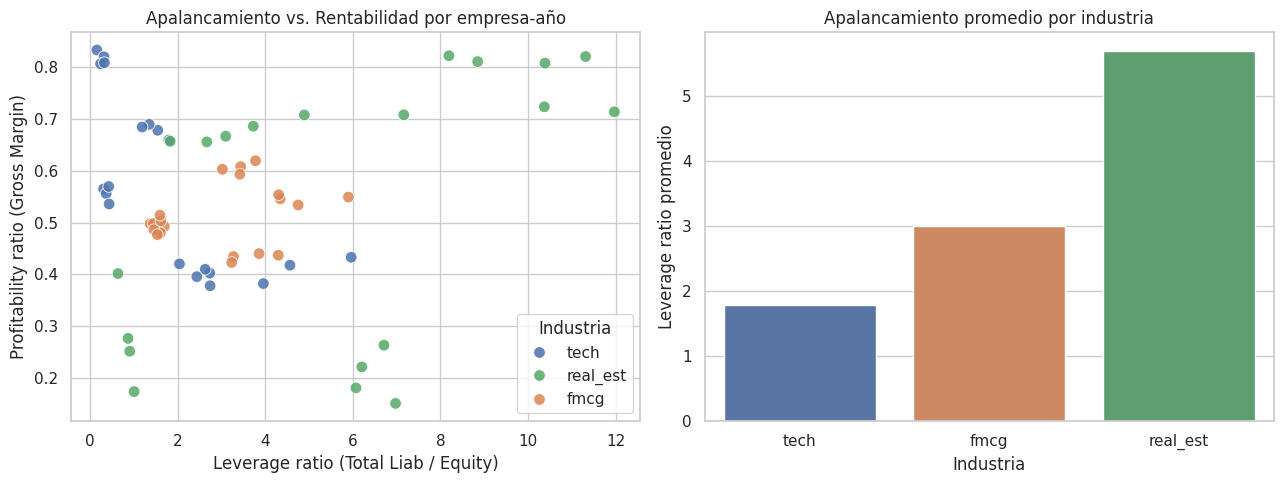

In [8]:
palette = {"tech": "#4C72B0", "fmcg": "#DD8452", "real_est": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=dfratios, x="leverageratio", y="profitabilityratio",
    hue="comp_type", palette=palette, s=70, alpha=0.85, ax=axes[0],
)
axes[0].set_title("Apalancamiento vs. Rentabilidad por empresa-año")
axes[0].set_xlabel("Leverage ratio (Total Liab / Equity)")
axes[0].set_ylabel("Profitability ratio (Gross Margin)")
axes[0].legend(title="Industria")

summary_plot = summary.reset_index().rename(columns={"index": "comp_type"})
summary_melt = summary_plot.melt(
    id_vars="comp_type", var_name="ratio", value_name="valor"
)
sns.barplot(
    data=summary[["leverageratio_avg"]].reset_index(),
    x="comp_type", y="leverageratio_avg", ax=axes[1],
    palette=palette, order=["tech", "fmcg", "real_est"],
)
axes[1].set_title("Apalancamiento promedio por industria")
axes[1].set_xlabel("Industria")
axes[1].set_ylabel("Leverage ratio promedio")

plt.tight_layout()
plt.savefig("images/leverage_vs_profitability.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Conclusiones

- **Rentabilidad más baja:** las empresas de **fmcg** (bienes de consumo masivo) muestran el margen
  bruto promedio más bajo del grupo — consistente con un negocio de alto volumen y márgenes
  ajustados por naturaleza competitiva.
- **Mayor apalancamiento:** las empresas de **real estate** son, por lejos, las más apalancadas
  (~5.7x deuda/patrimonio en promedio) — típico del sector, que financia activos de largo plazo
  (propiedades) con deuda.
- **Apalancamiento y rentabilidad en real estate:** existe una relación **positiva** (correlación ≈
  0.50) — dentro del sector inmobiliario, las empresas que usan más deuda tienden a mostrar también
  mayor margen bruto, probablemente porque el apalancamiento financiero amplifica el retorno sobre
  los activos que generan renta.

Estos resultados son coherentes con la teoría financiera: el apalancamiento no es "bueno" ni "malo"
en sí mismo, sino que su interpretación depende del sector y de la capacidad de la empresa de generar
flujos estables para sostener esa deuda (algo que analicé en la práctica al trabajar tesorería y
conciliaciones bancarias en Punto Ticket).


In [9]:
dfratios.to_csv("data/dfratios.csv", index=False)
print("dfratios guardado en data/dfratios.csv")


dfratios guardado en data/dfratios.csv
